# Inference

When people compare Bayesian inference with conventional approaches, p-values often come up. P-values result from t-tests, an example of null hypothesis significance testing. A common example could be comparing two groups to see if there is a difference in their mean. 

A Bayesian alternative is to compute the posterior distribution of the difference between the groups. Then you can use that distribution to answer whatever questions we are interested in like the most likely size of the difference, a credible interval that is likely to contain the true difference, the probability of superiority, or the probability that the difference exceeeds a given threshold. 

## Improving Reading Ability

We'll use data from a PhD dissertation in educational phychology written in 1987. An educator conducted an experiment to test whether new directed reading activities in the classroom will help elementary students improve aspects of their reading abilities. She arranged for one class to undergo a curriculum and activies for eight weeks while a control class simply did the curriculum. At the end of the period, both groups took a reading capabilities test. 

In [2]:
import pandas as pd

df = pd.read_csv('/Users/colelacroix/math/01_Think_Bayes_(Downey)/data/drp_scores.csv', skiprows = 21, delimiter = '\t')
df.head(3)

,Treatment,Response
0,Treated,24
1,Treated,43
2,Treated,58


In [3]:
# use groupby to separate into treatment and control groups

grouped = df.groupby('Treatment')
responses = {}

for name, group in grouped:
    responses [name] = group['Response']

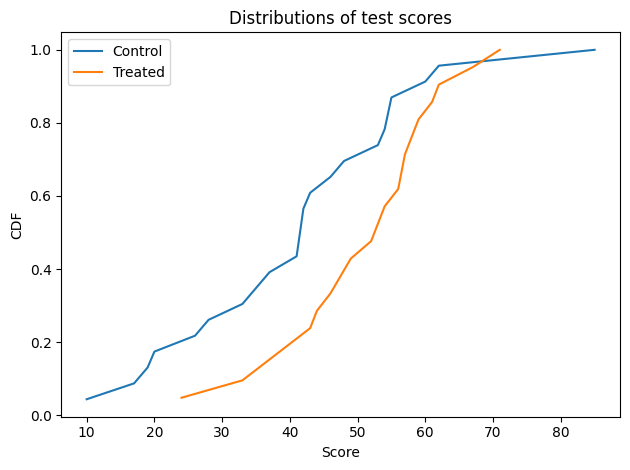

In [5]:
# Display CDF scores for the two groups

from empiricaldist import Cdf
from utils import decorate

for name, response in responses.items():
    cdf = Cdf.from_seq(response)
    cdf.plot(label=name)
    
decorate(xlabel='Score', 
         ylabel='CDF',
         title='Distributions of test scores')

There is overlap between the two groups but it does look like the treamtment group scores higher. The lines arent smooth but still look like a normal model is a reasonable choice. We'll use mu and sigma to to denote unknown parameters and do a Bayesian update to estimate what they are. 

## Estimating Parameters

As always, we need a prior distribution for our parameters. Since there are two parameters, it will be a joint distribution. We'll make it by choosing marginal distributions for each parameters and computing their outer product. 

As a simple starting place, let's assume that the priors for mu and sigma are uniform. The following function represents a uniform distribution:

In [7]:
from empiricaldist import Pmf

def make_uniform(qs, name = None, **options):
    """ make a Pmf that represents a uniform distribution """
    pmf = Pmf(1.0, qs, **options)
    pmf.normalize()
    if name:
        pmf.index.name = name
    return pmf

In [9]:
# prior distribution for mu

import numpy as np

qs = np.linspace(20, 80, num = 101)
prior_mu = make_uniform(qs, name = 'mean')

In [10]:
# prior distribution for sigma

qs = np.linspace(5, 30, num = 101)
prior_sigma = make_uniform(qs, name = 'std')

In [11]:
# make joint prior distribution

from utils import make_joint

prior = make_joint(prior_mu, prior_sigma)

In [12]:
# take a look at control group

data = responses['Control']
data.shape

(23,)

## Likelihood

Next, we would like to know the probability of eahc score in the dataset for each hypothetical pair of values, mu and sigma. We'll do this by making a 3 dimensional grid with values of mu on the first axis, values of sigma on the second axis, and scores from the dataset on the third axis. 

In [13]:
mu_mesh, sigma_mesh, data_mesh = np.meshgrid(prior.columns, prior.index, data)

mu_mesh.shape

(101, 101, 23)

In [14]:
# use norm.pdf to compute prob density of each score for each hypothetical pair of parameters

from scipy.stats import norm

densities = norm(mu_mesh, sigma_mesh).pdf(data_mesh)
densities.shape

(101, 101, 23)

The result is a 3D array. To compute likelihoods, we multiply these densities along axis = 2

In [15]:
likelihood = densities.prod(axis = 2)
likelihood.shape

(101, 101)

The result is a 2D array that contains the likelihood of the entire dataset for each hypothetical pair of parameters. We can use this array to update the prior. 

In [16]:
from utils import normalize

posterior = prior * likelihood
normalize(posterior)
posterior.shape

(101, 101)

The result is a DataFrame that represents the joint posterior distribution. Let's build a function to automate these steps:

In [17]:
def update_norm(prior, data):
    """ update the prior based on data """
    mu_mesh, sigma_mesh, data_mesh = np.meshgrid(prior.columns, prior.index, data)

    densities = norm(mu_mesh, sigma_mesh).pdf(data_mesh)
    likelihood = densities.prod(axis = 2)

    posterior = prior * likelihood
    normalize(posterior)

    return posterior

In [18]:
data = responses['Control']
posterior_control = update_norm(prior, data)

data = responses['Treated']
posterior_treated  = update_norm(prior, data)

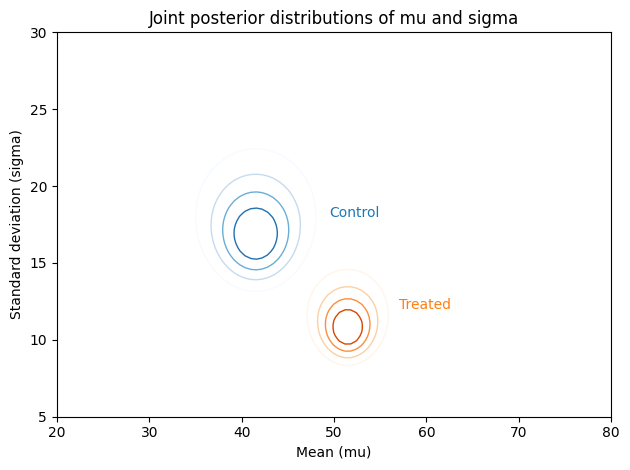

In [19]:
import matplotlib.pyplot as plt
from utils import plot_contour

plot_contour(posterior_control, cmap='Blues')
plt.text(49.5, 18, 'Control', color='C0')

cs = plot_contour(posterior_treated, cmap='Oranges')
plt.text(57, 12, 'Treated', color='C1')

decorate(xlabel='Mean (mu)', 
         ylabel='Standard deviation (sigma)',
         title='Joint posterior distributions of mu and sigma')

Along the x-axis, the mean score for the treated group is higher. Along the y-axis, the standard deviation for the treated group is lower. 

## Posterior Marginal Distributions

In [20]:
from utils import marginal

pmf_mean_control = marginal(posterior_control, 0)
pmf_mean_treated = marginal(posterior_treated, 0)

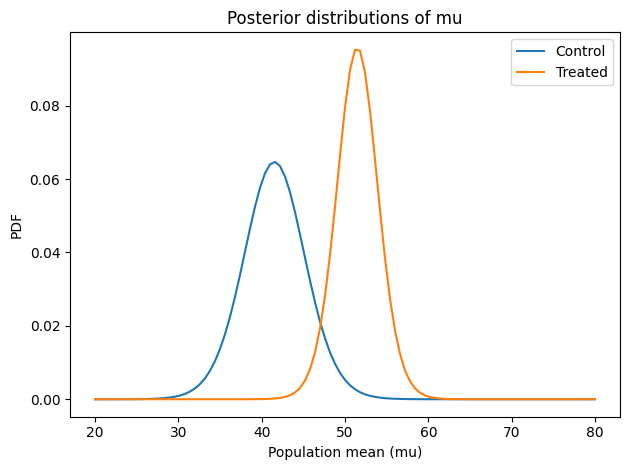

In [21]:
pmf_mean_control.plot(label='Control')
pmf_mean_treated.plot(label='Treated')

decorate(xlabel='Population mean (mu)', 
         ylabel='PDF', 
         title='Posterior distributions of mu')

In both cases the posterio probabilities at the ends of the range are near zero which means the bounds we chose for the prior distributions were wide enough. It appears that the mean of the treated group is higher. We can use prob_gt to compute the probability of superiority:

In [22]:
Pmf.prob_gt(pmf_mean_treated, pmf_mean_control)

np.float64(0.9804790251873261)

## Distribution of Differences

To quantify the magnitude of the difference between the groups, we can use sub_dist to compute the distribution of the difference:

In [23]:
pmf_diff = Pmf.sub_dist(pmf_mean_treated, pmf_mean_control)

In [24]:
len(pmf_mean_treated), len(pmf_mean_control), len(pmf_diff)

(101, 101, 879)

In the worst case, the size of the result can be the product of the originals. 

Two cautions:
- The results can contain many more elements than the original Pmf. In this example the increase in size is only moderate.
- Plotting the distribution can be quite noisy. 

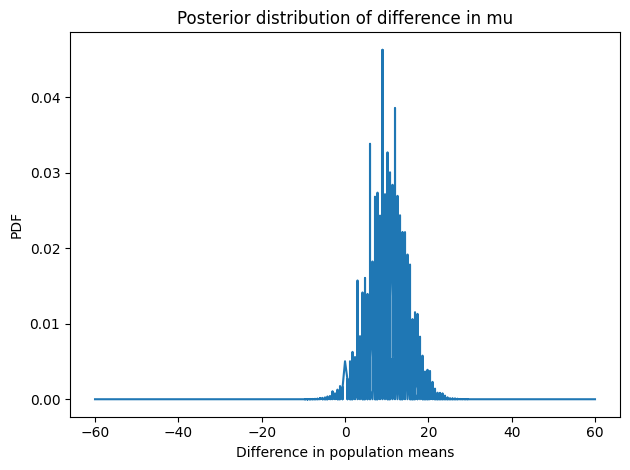

In [25]:
pmf_diff.plot()

decorate(xlabel='Difference in population means', 
         ylabel='PDF', 
         title='Posterior distribution of difference in mu')

You can get around this by plotting the CDF instead:

In [26]:
cdf_diff = pmf_diff.make_cdf()

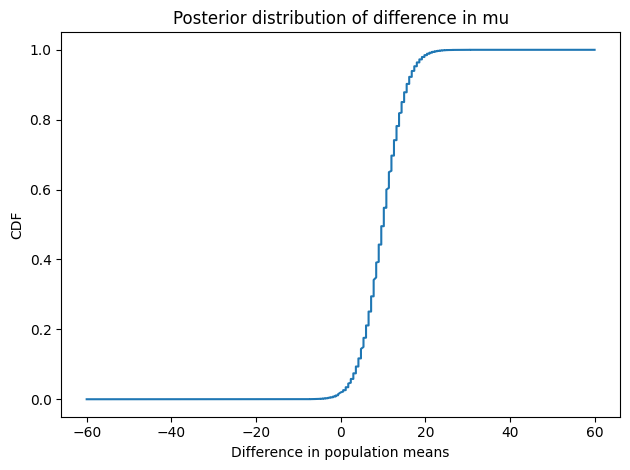

In [27]:
cdf_diff.plot()

decorate(xlabel='Difference in population means', 
         ylabel='CDF', 
         title='Posterior distribution of difference in mu')

The other option is to use the kernel density estimation to make a smooth approximation of the PDF on an equally spaced grid. 

In [34]:
from scipy.stats import gaussian_kde

def kde_from_pmf(pmf, n=101):
    """Make a kernel density estimate for a PMF."""
    kde = gaussian_kde(pmf.qs, weights = pmf.ps)
    qs = np.linspace(pmf.qs.min(), pmf.qs.max(), n)
    ps = kde.evaluate(qs)
    pmf = Pmf(ps, qs)
    pmf.normalize()
    return pmf

In [35]:
kde_diff = kde_from_pmf(pmf_diff)

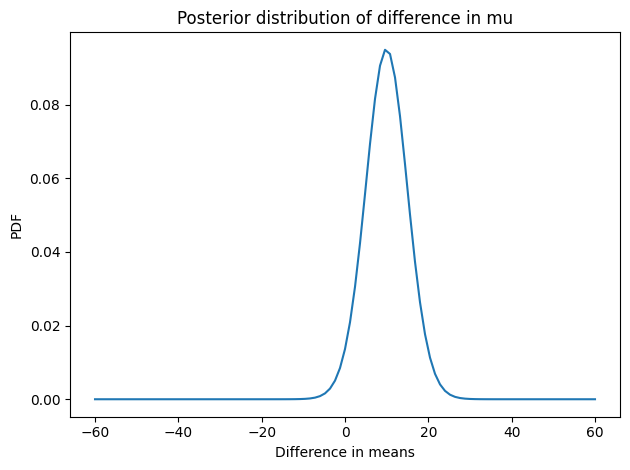

In [36]:
kde_diff.plot()

decorate(xlabel='Difference in means', 
         ylabel='PDF', 
         title='Posterior distribution of difference in mu')

The mean of this distribution is almost 10 points on a test where the mean score is 45. So the treatment seems substantial. 

In [37]:
pmf_diff.mean()

np.float64(9.954413088940848)

## Using Summary Statistics

This dataset is not very big so it doesn't take long to compute the probability of every score under every hypothesis. For larger datasets, it might be too big to compute practically. An alternative is to compute a summary of the dataset and compute the likelihood of the summary. For example, we can compute the mean and the standard deviation followed by the likelihood of those summary statistics under each hypothesis. 

In [43]:
mu = 42
sigma = 17

In [44]:
# draw a sample: mean = m, std dev = s, sample size = n

n = 20
m = 41
s = 18

The summary stats are not too far from mu and sigma so they are probably not too unlikely. To compute their likelihood, we will use three results from mathematical statistics:

- Given mu and sigma, the distribution of m is normal with parameters m and sigma/ sqrt(n)
- The distribution of s is more complicated. But, if we compute the transform t = ns^2 / sigma^2, the distribution is chi-squared with parameter n - 1.
- And, according to Basu's theorem, m and s are independent.

So, let's compute the likelihood of m and s given mu and sigma. 

In [45]:
# create norm object that represents distribution of m

dist_m = norm(mu, sigma/np.sqrt(n))

In [46]:
like1 = dist_m.pdf(m)
like1

np.float64(0.10137915138497372)

In [47]:
# compute likelihood of the observed value of s

t = n * s**2 / sigma**2
t

22.422145328719722

In [48]:
# create chi2 object to represent the distribution of t

from scipy.stats import chi2

dist_s = chi2(n-1)

In [49]:
# compute likelihood of t

like2 = dist_s.pdf(t)
like2

np.float64(0.04736427909437004)

Finally, m and s are independent, so their joint likelihood is the product of their likelihoods

In [50]:
like = like1 * like2
like

np.float64(0.004801750420548287)

Now we can compute the likelihood of the data for any values of mu and sigma, which we'll use in the next section to do the update. 

## Update with Summary Statistics

In [51]:
summary = {}

for name, response in responses.items():
    summary[name] = len(response), response.mean(), response.std()

summary

{'Control': (23,
  np.float64(41.52173913043478),
  np.float64(17.148733229699484)),
 'Treated': (21,
  np.float64(51.476190476190474),
  np.float64(11.00735684721381))}

In [54]:
# demonstrate update with summary stats from control

n, m, s = summary['Control']

In [55]:
# make mesh with hypothetical values of mu on x, sigma on y

mus, sigmas = np.meshgrid(prior.columns, prior.index)
mus.shape

(101, 101)

In [56]:
# compute likelihood of seeing sample mean, m, for each pair of parameters

like1 = norm(mus, sigmas/np.sqrt(n)).pdf(m)
like1.shape

(101, 101)

In [57]:
# compute likelihood of standard deviation, s, for each pair of parameters

ts = n * s**2 / sigmas**2
like2 = chi2(n-1).pdf(ts)
like2.shape

(101, 101)

In [61]:
posterior_control2 = prior * like1 * like2
normalize(posterior_control2)

np.float64(0.00030965351017402847)

In [62]:
# compute posterior distribution

def update_norm_summary(prior, data):
    """Update a normal distribution using summary statistics."""
    n, m, s = data
    mu_mesh, sigma_mesh = np.meshgrid(prior.columns, prior.index)
    
    like1 = norm(mu_mesh, sigma_mesh/np.sqrt(n)).pdf(m)
    like2 = chi2(n-1).pdf(n * s**2 / sigma_mesh**2)
    
    posterior = prior * like1 * like2
    normalize(posterior)
    
    return posterior

In [63]:
data = summary['Treated']
posterior_treated2 = update_norm_summary(prior, data)

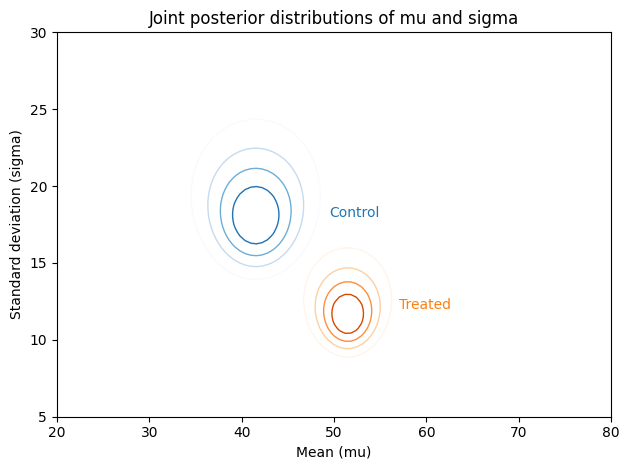

In [64]:
plot_contour(posterior_control2, cmap='Blues')
plt.text(49.5, 18, 'Control', color='C0')

cs = plot_contour(posterior_treated2, cmap='Oranges')
plt.text(57, 12, 'Treated', color='C1')

decorate(xlabel='Mean (mu)', 
         ylabel='Standard deviation (sigma)',
         title='Joint posterior distributions of mu and sigma')

Visually, these might look the same as the ones we computed using the entire dataset though they are not. We can compare them in the next section. 

## Comparing Marginals

In [65]:
from utils import marginal

pmf_mean_control2 = marginal(posterior_control2, 0)
pmf_mean_treated2 = marginal(posterior_treated2, 0)

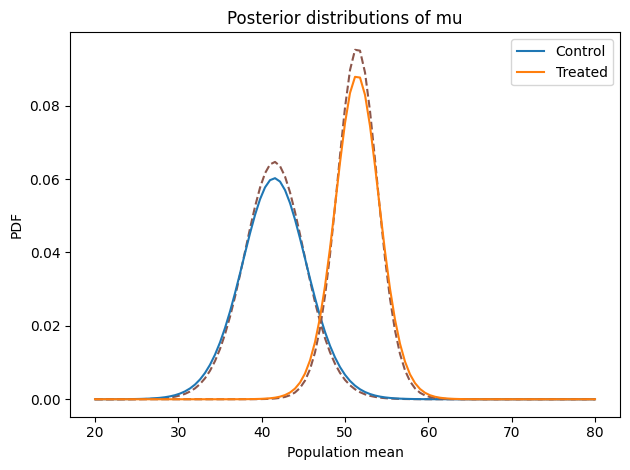

In [66]:
pmf_mean_control.plot(color='C5', ls='--')
pmf_mean_control2.plot(label='Control')
pmf_mean_treated.plot(color='C5', ls='--')
pmf_mean_treated2.plot(label='Treated')

decorate(xlabel='Population mean', 
         ylabel='PDF', 
         title='Posterior distributions of mu')

The posterior distributions based on summary stats are similar to the posteriors we computed using the entire dataset. However, because we used summary stats, we lost some information and the result is less certain as reflected in the distribution. 

## Proof by Simulation

In [67]:
mu = 42
sigma = 17

In [68]:
dist = norm(mu, sigma)

In [69]:
n = 20
samples = dist.rvs((1000, n))
samples.shape

(1000, 20)

In [74]:
sample_means = samples.mean(axis = 1)
sample_means.shape

(1000,)

In [75]:
def pmf_from_dist(dist, low, high):
    """Make a discrete approximation of a continuous distribution.
    
    dist: SciPy dist object
    low: low end of range
    high: high end of range
    
    returns: normalized Pmf
    """
    qs = np.linspace(low, high, 101)
    ps = dist.pdf(qs)
    pmf = Pmf(ps, qs)
    pmf.normalize()
    return pmf

In [76]:
# six standard deviations

low = dist_m.mean() - dist_m.std() * 3
high = dist_m.mean() + dist_m.std() * 3

pmf_m = pmf_from_dist(dist_m, low, high)

In [77]:
from utils import kde_from_sample

qs = pmf_m.qs
pmf_sample_means = kde_from_sample(sample_means, qs)

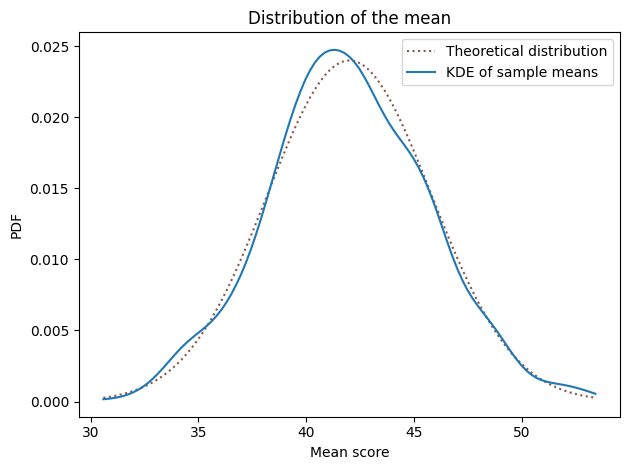

In [78]:
pmf_m.plot(label='Theoretical distribution',
           ls=':', color='C5')
pmf_sample_means.plot(label='KDE of sample means')

decorate(xlabel='Mean score',
         ylabel='PDF',
         title='Distribution of the mean')

## Check Standard Deviation

In [79]:
sample_stds = samples.std(axis=1)
sample_stds.shape

(1000,)

In [80]:
# compute transformed values

transformed = n * sample_stds**2 / sigma**2

In [81]:
from scipy.stats import chi2

dist_s = chi2(n-1)

In [82]:
low = 0
high = dist_s.mean() + dist_s.std() * 4

pmf_s = pmf_from_dist(dist_s, low, high)

In [83]:
# use kde to estimate the distribution of the sample standard deviations

qs = pmf_s.qs
pmf_sample_stds = kde_from_sample(transformed, qs)

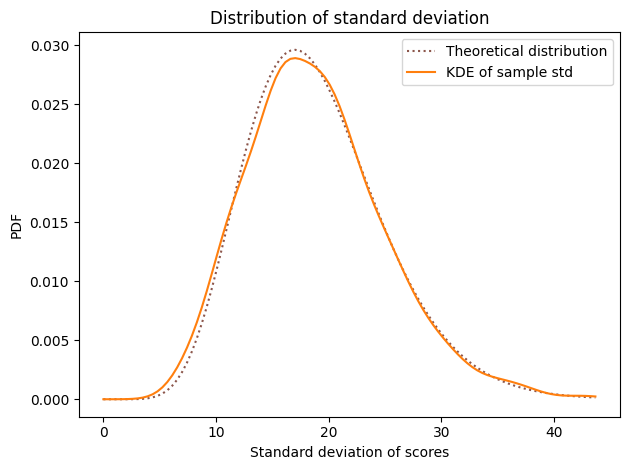

In [84]:
pmf_s.plot(label='Theoretical distribution',
           ls=':', color='C5')
pmf_sample_stds.plot(label='KDE of sample std',
                     color='C1')

decorate(xlabel='Standard deviation of scores',
         ylabel='PDF',
         title='Distribution of standard deviation')

In [85]:
# comopute coefficient of correlation

np.corrcoef(sample_means, sample_stds)[0][1]

np.float64(-0.005915981439385567)

The correlation is near zero which is consistent with their being independent. 

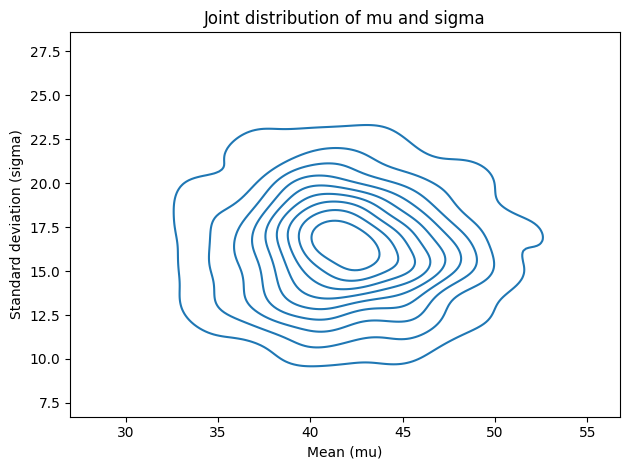

In [86]:
import seaborn as sns

sns.kdeplot(x=sample_means, y=sample_stds)

decorate(xlabel='Mean (mu)',
         ylabel='Standard deviation (sigma)',
         title='Joint distribution of mu and sigma')